# Model Comparison Chart
Generate a side-by-side comparison of Random Forest vs Decision Tree performance metrics.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Real results from train_model_comparison.py
models    = ['Random Forest', 'Decision Tree']
accuracy  = [0.851, 0.872]
f1_active = [0.86,  0.88]
f1_sed    = [0.84,  0.87]
cv_mean   = [0.876, 0.833]
cv_std    = [0.077, 0.100]

x = np.arange(len(models))
w = 0.2

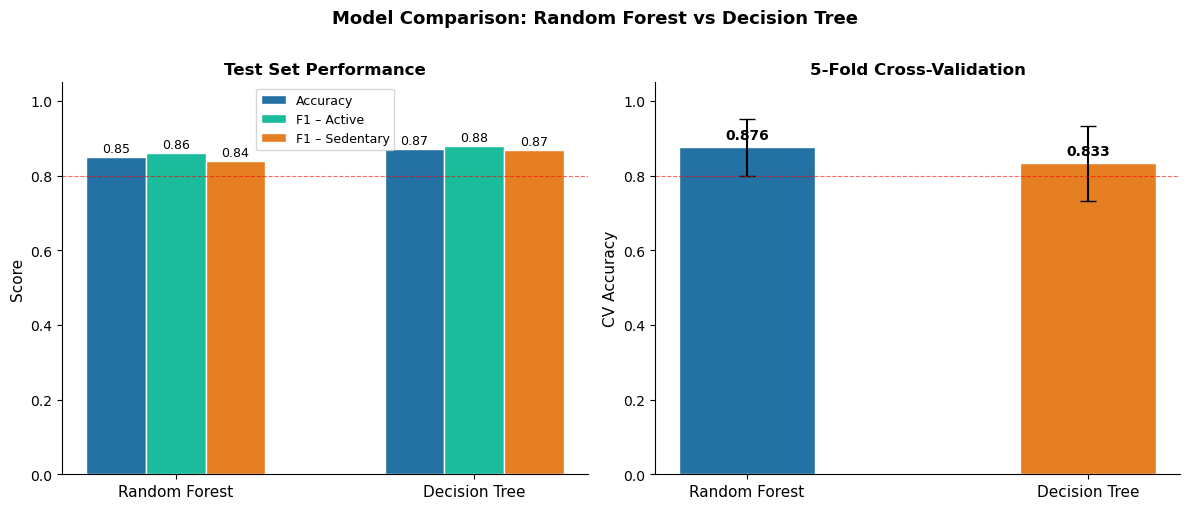

Saved model_comparison.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left panel: test set accuracy and F1
ax = axes[0]
b1 = ax.bar(x - w,  accuracy,  w, label='Accuracy',       color='#2471A3', edgecolor='white')
b2 = ax.bar(x,      f1_active, w, label='F1 – Active',    color='#1ABC9C', edgecolor='white')
b3 = ax.bar(x + w,  f1_sed,    w, label='F1 – Sedentary', color='#E67E22', edgecolor='white')

for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x); ax.set_xticklabels(models, fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Test Set Performance', fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.axhline(0.80, color='red', linewidth=0.8, linestyle='--', alpha=0.6)

# Right panel: 5-fold CV with error bars
ax2 = axes[1]
bars2 = ax2.bar(x, cv_mean, 0.4, color=['#2471A3', '#E67E22'], edgecolor='white',
                yerr=cv_std, capsize=6, error_kw={'linewidth': 1.5})

for bar, val in zip(bars2, cv_mean):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.015,
             f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2.set_xticks(x); ax2.set_xticklabels(models, fontsize=11)
ax2.set_ylabel('CV Accuracy', fontsize=11)
ax2.set_title('5-Fold Cross-Validation', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 1.05)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.axhline(0.80, color='red', linewidth=0.8, linestyle='--', alpha=0.6)

fig.suptitle('Model Comparison: Random Forest vs Decision Tree',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved model_comparison.png")